# 2 · Evaluating a configuration

In [2]:
# This is just the code header, ignore it.
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dse
import dse.plots as plots
from dse import DATA, WORK

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

We want the feasible configuration with the lowest latency. Try to find a good one.

Pick a value for each parameter. The dropdowns only offer values that still lead to a feasible configuration. When one configuration is left, press **Simulate**: Cinnamon compiles the program with that configuration and the simulator estimates its latency.

- `tasklets`: threads per DPU
- `gemv.M.mram`, `gemv.K.mram`: the tile of `A` each (DPU, tasklet) worker holds in MRAM (M = rows of A, K = columns of A)
- `gemv.M.wram`, `gemv.K.wram`: the smaller tile a tasklet loads into WRAM at a time
- `gemv.order`: which dimension is spread across DPUs first

In [3]:
mlir = DATA / "small" / "gemv.mlir"
space = dse.load_space(DATA / "small" / "space.json")
# The feasible configurations, which the dropdowns are restricted to
feasible = dse.load_pool(DATA / "small" / "pool.csv")[lambda p: dse.param_columns(p)]

picker = dse.ConfigPicker(feasible, space, on_pick=lambda config: dse.lower(mlir, config)).show()

If you skipped the picker, this uses a default configuration (all tasklets, mid-sized tiles).

In [4]:
lowering = picker.result or dse.lower(mlir, picker.default_guess())
lowering.config

{'dpus': 64,
 'tasklets': 16,
 'gemv.M.mram': 32,
 'gemv.M.wram': 4,
 'gemv.K.mram': 32,
 'gemv.K.wram': 32,
 'gemv.order[0]': 2,
 'gemv.order[1]': 1}

## The lowering

Cinnamon lowers the program in several steps. Below is the IR at some of them, for your configuration. Long lines scroll sideways.

### linalg

`cinm.op.gemv` becomes `linalg.matvec`. Nothing is tiled or distributed yet.

In [5]:
dse.show_mlir(lowering.stages["after-cinm-to-linalg"])

### cnm

The computation is split over a workgroup of DPUs x tasklets. 
- `cnm.scatter` sends the pieces of `A` and `x` to per-worker buffers
- `cnm.launch` runs the kernel on every worker tasklet
- `cnm.gather` collects `y`

The buffer shapes follow from your MRAM tile sizes. (buffers are annotated #upmem.mram).

If `gemv.K.mram` is less than the full K extent, each worker computes a partial result that must be reduced on the host. In this case you'll see a `linalg.generic` implementing the reduction at the end.


In [6]:
dse.show_mlir(lowering.stages["after-linalg-to-cnm"])

### WRAM tiling

Two things have happened here:
- bufferization: that's the conversion of tensors (value-semantics) to memrefs (buffer semantics). Bufferization is a builtin pass in MLIR. It tries to reduce the number of allocations. Usually here you'll see a `memref.alloc` operator for the output buffer, and another for the partial result buffers, if DPUs don't compute full results.
- WRAM tiling: inside the `cnm.launch`, WRAM buffers are now present, allocated via `memref.alloca`. There's a loop that wraps the per-WRAM-tile computation, each time it transfers the WRAM tile from MRAM into the WRAM buffer with `cnm.local_transfer` before computing on them, and writing back into MRAM.

In [7]:
dse.show_mlir(lowering.stages["after-tile-mram-buffers"])

### upmem

The final program in the `upmem` dialect: allocating DPUs, loading the kernel, transfers between host and DPUs, and the code each tasklet runs. 

This representation is very close to the code that will actually be run. The host part (`@gemv`) can be translated in one step to LLVM IR; the DPU kernel (`@program`), which is now isolated in another module, will be lowered to C and compiled with the UPMEM SDK compiler.

This is whose latency is estimated via simulation.

In [8]:
dse.show_mlir(lowering.output)

## The estimate

When running the latency estimator on the above program, you get the following breakdown:

In [9]:
lowering.report

kernel,0.777
kernel.launchOverhead,0.046
cpu.compact,6.658
cpu.other,0.013
transfer.array,0.339
transfer_back.array,0.103


The estimate is the sum of:
- `kernel`: the DPU kernel, from the cycle-accurate simulator
- `kernel.launchOverhead`: the cost of launching it, calibrated on real hardware
- `cpu.compact`: rearranging data on the host before a transfer
- `cpu.other`: other host work, such as reductions done on the host
- `transfer.array`, `transfer.broadcast`: sending data to the DPUs (different data to each, or the same to all)
- `transfer_back.array`: getting the result back

Not every configuration has every term.

## How good is your configuration?

We simulated every feasible configuration in advance so that you can check where yours ranks.

In [10]:
oracle = dse.load_pool(DATA / "small" / "pool.csv")
best = oracle["cost"].min()
median = oracle["cost"].median()
mine = lowering.report.total_ms

print(f"{len(oracle)} feasible configurations")
print(f"best   {best:7.2f} ms")
print(f"median {median:7.2f} ms")
print(f"yours  {mine:7.2f} ms, rank {dse.rank_of(mine, oracle)} of {len(oracle)}")

3234 feasible configurations
best      1.60 ms
median    9.50 ms
yours     7.93 ms, rank 145 of 3234


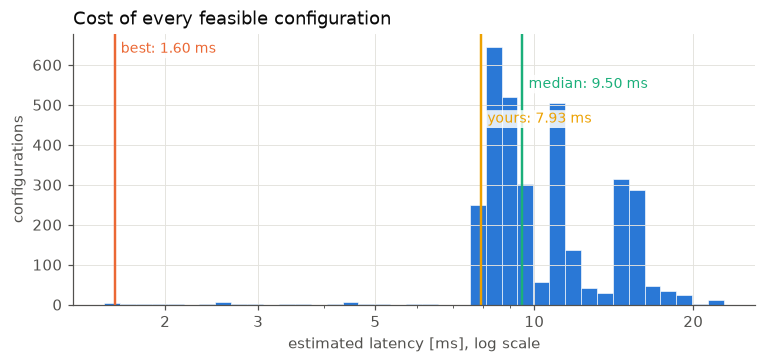

within 1.1× of the best: 6 configurations
within 1.5× of the best: 11 configurations
within 2× of the best: 19 configurations


In [11]:
plots.cost_histogram(oracle, {"best": best, "median": median, "yours": mine})
plt.show()

for f in (1.1, 1.5, 2):
    print(f"within {f}× of the best: {(oracle['cost'] <= f * best).sum()} configurations")

Most configurations are within a factor of two of the median. Only a few are close to the best one, so sampling at random is unlikely to find them.

The best configurations:

In [12]:
cols = dse.param_columns(oracle) + ["cost"]
oracle.sort_values("cost").head(5)[cols].style.format({"cost": "{:.3f}"}).hide(axis="index")

dpus,tasklets,gemv.M.mram,gemv.M.wram,gemv.K.mram,gemv.K.wram,gemv.order[0],gemv.order[1],cost
64,8,2,1,1024,64,1,2,1.604
64,8,2,1,1024,128,1,2,1.614
64,8,2,1,1024,32,1,2,1.630
64,8,2,1,1024,512,1,2,1.642
64,8,2,1,1024,16,1,2,1.648


Next: finding these without simulating every configuration (notebook 3).